In [5]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 13})
warnings.filterwarnings('ignore')

from sklearn.svm import SVC
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Load saved .npy files
svm_mean_proba    = np.load('svm_mean_proba.npy')
qsvm_mean_proba   = np.load('qsvm_mean_proba.npy')
ensemble_proba    = np.load('ensemble_proba.npy')
ensemble_pred     = np.load('ensemble_final_pred.npy')
y_test            = np.load('y_test.npy')
svm_proba_matrix  = np.load('svm_proba_matrix.npy')
qsvm_proba_matrix = np.load('qsvm_proba_matrix.npy')

svm_soft_pred  = (svm_mean_proba  >= 0.5).astype(int)
qsvm_soft_pred = (qsvm_mean_proba >= 0.5).astype(int)
y_true = y_test

# Rebuild dataset and preprocessing
df = pd.read_csv("email_phishing_dataset_FINAL.csv")
df = df.dropna(subset=['email_from_domain'])
df['domain_age_missing'] = df['domain_age'].isnull().astype(int)
df['domain_age'] = df['domain_age'].fillna(0)

df_encoded = df.copy()

# Frequency encoding
domain_freq = df_encoded['email_from_domain'].value_counts(normalize=True)
df_encoded['email_domain_freq'] = (df_encoded['email_from_domain']
                                    .map(domain_freq).fillna(0))
df_encoded.drop(['email_from_domain'], axis=1, inplace=True)

geo_freq = df_encoded['web_geo_loc'].value_counts(normalize=True)
df_encoded['web_geo_loc'] = df_encoded['web_geo_loc'].map(geo_freq).fillna(0)

# Binary encodings
trusted_tlds = ['com', 'org', 'net', 'edu', 'gov']
df_encoded['web_tld'] = df_encoded['web_tld'].apply(
    lambda x: 1.0 if str(x).lower() in trusted_tlds else 0.0
)
df_encoded['web_who_is'] = (df_encoded['web_who_is'] == 'complete').astype(int)
df_encoded['web_https']  = (df_encoded['web_https']  == 'yes').astype(int)

# Drop raw text columns
for col in ['web_url', 'web_ip_add', 'web_content']:
    if col in df_encoded.columns:
        df_encoded.drop(col, axis=1, inplace=True)

# Split + scale 
X = df_encoded.drop('final_label', axis=1)
y = df_encoded['final_label']

X_train, X_test_df, y_train, y_test_df = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_train.columns
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_df), columns=X_test_df.columns
)

# Feature selection 
mi_scores = mutual_info_classif(X_train_scaled, y_train, random_state=42)
mi_df = pd.DataFrame({
    'feature':  X_train.columns,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False)

top_features = mi_df.head(6)['feature'].tolist()
X_train_selected = X_train_scaled[top_features]
X_test_selected  = X_test_scaled[top_features]

print("Setup complete.")
print(f"Top 6 features: {top_features}")


Setup complete.
Top 6 features: ['web_js_len', 'js_obfuscation_ratio', 'web_js_obf_len', 'content_num_scripts', 'content_entropy', 'domain_trust_score']


NOISE ANALYSIS — QSVM under depolarizing noise
Training: 50 samples  |  Test: 50 samples
p=0.000  Ideal (no noise)              Acc=0.9400  F1=0.9400  Deg=0.0%  Time=0.3min
p=0.001  Depolarizing p=0.001          Acc=0.9400  F1=0.9400  Deg=0.0%  Time=0.3min
p=0.005  Depolarizing p=0.005          Acc=0.9400  F1=0.9400  Deg=0.0%  Time=0.3min
p=0.010  Depolarizing p=0.01           Acc=0.9400  F1=0.9400  Deg=0.0%  Time=0.3min
p=0.050  Depolarizing p=0.05           Acc=0.8400  F1=0.8377  Deg=10.6%  Time=0.3min

Noise Analysis Results:
 Noise Level (p)        Configuration  Accuracy  Macro F1-Score  Degradation (%)  Training Time (min)
           0.000     Ideal (no noise)      0.94          0.9400             0.00                  0.3
           0.001 Depolarizing p=0.001      0.94          0.9400             0.00                  0.3
           0.005 Depolarizing p=0.005      0.94          0.9400             0.00                  0.3
           0.010  Depolarizing p=0.01      0.94          

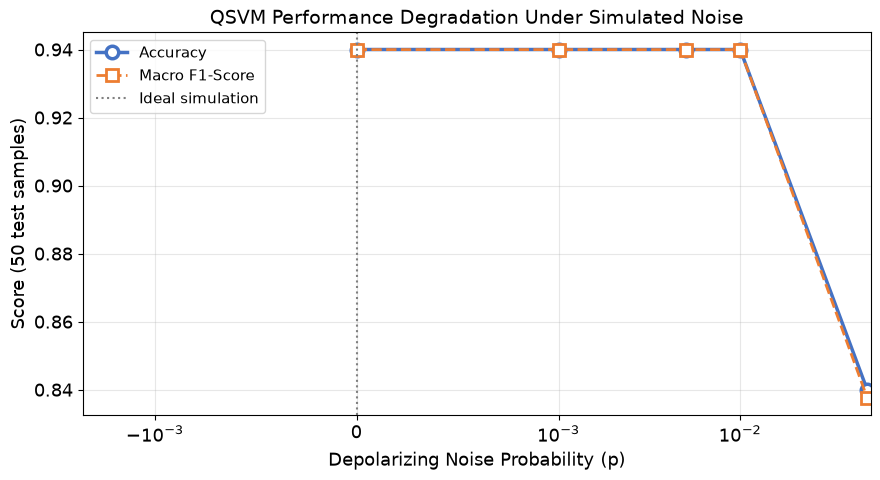

Saved: noise_analysis_plot.png


In [6]:
from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC
from qiskit_algorithms.state_fidelities import ComputeUncompute  # ← wrap sampler in this
from qiskit.primitives import Sampler
from qiskit_aer.primitives import Sampler as AerSampler
from qiskit_aer.noise import NoiseModel, depolarizing_error
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import numpy as np
import time

np.random.seed(42)

idx       = np.random.choice(len(X_train_selected), 50, replace=False)
X_train_s = X_train_selected.values[idx] * np.pi
y_train_s = y_train.values[idx]
X_test_s  = X_test_selected.values[:50] * np.pi
y_test_s  = y_test_df.values[:50]

feature_map = ZZFeatureMap(feature_dimension=6, reps=1, entanglement='linear')

noise_levels = [0.0, 0.001, 0.005, 0.01, 0.05]
results      = {}

print("NOISE ANALYSIS — QSVM under depolarizing noise")
print(f"Training: 50 samples  |  Test: 50 samples")
print("="*60)

for p in noise_levels:
    start = time.time()

    if p == 0.0:
        # Ideal 
        sampler  = Sampler()
        fidelity = ComputeUncompute(sampler=sampler)
        label    = "Ideal (no noise)"

    else:
        # Noisy
        noise_model = NoiseModel()
        noise_model.add_all_qubit_quantum_error(
            depolarizing_error(p, 1), ['h', 'p', 'rz', 'rx', 'ry']
        )
        noise_model.add_all_qubit_quantum_error(
            depolarizing_error(p * 2, 2), ['cx', 'cz']
        )
        sampler = AerSampler()
        sampler.set_options(
            noise_model=noise_model,
            shots=1024,
            seed_simulator=42
        )
        fidelity = ComputeUncompute(sampler=sampler)
        label    = f"Depolarizing p={p}"

    qkernel = FidelityQuantumKernel(
        feature_map=feature_map,
        fidelity=fidelity          
    )

    try:
        model = QSVC(quantum_kernel=qkernel, C=1.0)
        model.fit(X_train_s, y_train_s)
        pred = model.predict(X_test_s)

        acc     = accuracy_score(y_test_s, pred)
        f1      = f1_score(y_test_s, pred, average='macro')
        elapsed = time.time() - start

        results[p] = {'acc': acc, 'f1': f1, 'label': label, 'time': elapsed}

        ideal_acc   = results[0.0]['acc'] if 0.0 in results else acc
        degradation = (ideal_acc - acc) / ideal_acc * 100 if p > 0 else 0.0

        print(f"p={p:.3f}  {label:<28}"
              f"  Acc={acc:.4f}  F1={f1:.4f}"
              f"  Deg={degradation:.1f}%"
              f"  Time={elapsed/60:.1f}min")

    except Exception as e:
        print(f"p={p:.3f} FAILED: {e}")
        results[p] = None

# Results table 
import pandas as pd
rows = []
ideal_acc = results.get(0.0, {}).get('acc') if results.get(0.0) else None

for p, res in results.items():
    if res is not None:
        deg = ((ideal_acc - res['acc']) / ideal_acc * 100
               if ideal_acc and p > 0 else 0.0)
        rows.append({
            'Noise Level (p)':     p,
            'Configuration':       res['label'],
            'Accuracy':            round(res['acc'], 4),
            'Macro F1-Score':      round(res['f1'],  4),
            'Degradation (%)':     round(deg, 2),
            'Training Time (min)': round(res['time'] / 60, 1)
        })

noise_df = pd.DataFrame(rows)
print("\nNoise Analysis Results:")
print(noise_df.to_string(index=False))
noise_df.to_csv('noise_analysis_results.csv', index=False)
print("Saved: noise_analysis_results.csv")

# Plot
valid = {p: r for p, r in results.items() if r is not None}
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(valid.keys()), [v['acc'] for v in valid.values()],
        'o-', color='#4472C4', linewidth=2.5, markersize=9,
        markerfacecolor='white', markeredgewidth=2.5, label='Accuracy')
ax.plot(list(valid.keys()), [v['f1'] for v in valid.values()],
        's--', color='#ED7D31', linewidth=2.0, markersize=8,
        markerfacecolor='white', markeredgewidth=2.0, label='Macro F1-Score')
ax.axvline(x=0, color='gray', linestyle=':', linewidth=1.5, label='Ideal simulation')
ax.set_xlabel('Depolarizing Noise Probability (p)', fontsize=13)
ax.set_ylabel('Score (50 test samples)', fontsize=13)
ax.set_title('QSVM Performance Degradation Under Simulated Noise', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xscale('symlog', linthresh=0.001)
plt.tight_layout()
plt.savefig('noise_analysis_plot.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: noise_analysis_plot.png")

In [7]:
import sys
import qiskit
import qiskit_aer
import qiskit_machine_learning
import sklearn
import numpy as np
import pandas as pd
import platform

print("SOFTWARE VERSIONS")
print(f"Python: {sys.version.split()[0]}")
print(f"Qiskit: {qiskit.__version__}")
print(f"Qiskit Aer: {qiskit_aer.__version__}")
print(f"Qiskit Machine Learning: {qiskit_machine_learning.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")



SOFTWARE VERSIONS
Python: 3.11.0
Qiskit: 1.4.5
Qiskit Aer: 0.13.3
Qiskit Machine Learning: 0.7.2
Scikit-learn: 1.9.0
NumPy: 1.26.4
Pandas: 3.0.4
